In [1]:
import numpy as np
import torch

from tqdm import tqdm
from matplotlib import pyplot as plt

# from utils import generate_run_ID, load_trained_weights
from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
# from get_data import get_traj_loader, generate_traj_data
from src.model import RNN
from src.trainer import Trainer
from src.utils import generate_run_ID
from src.visualize import *

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
%load_ext autoreload
%autoreload 2

# Basic explorations

In [91]:
# Training options and hyperparameters
class Options:
    pass
options = Options()

# options.save_dir = '/mnt/fs2/bsorsch/grid_cells/models/'
options.batch_size = 10   # number of trajectories per batch
options.sequence_length = 10  # number of steps in trajectory
options.Np = 512              # number of place cells
options.Ng = 2048            # number of grid cells
options.place_cell_rf = 0.07  # width of place cell center tuning curve (m)
options.rf_std = 0.05
options.place_cell_rf_prob = [0.65, 0.2, 0.15]  # probability of a place cell having a small, medium, or large RF
options.surround_scale = 2    # if DoG, ratio of sigma2^2 to sigma1^2
options.DoG = True   # use difference of gaussians tuning curves
options.periodic = False      # trajectories with periodic boundary conditions
options.box_width = 1.6      # width of training environment
options.box_height = 1.6      # height of training environment
options.device = device       # specify devices
options.normalize_pc = 'softmax'
options.dt = [0.02]

In [92]:
place_cells = PlaceCells(options)
trajectory_generator = TrajectoryGenerator(options, place_cells, environment='rectangle')

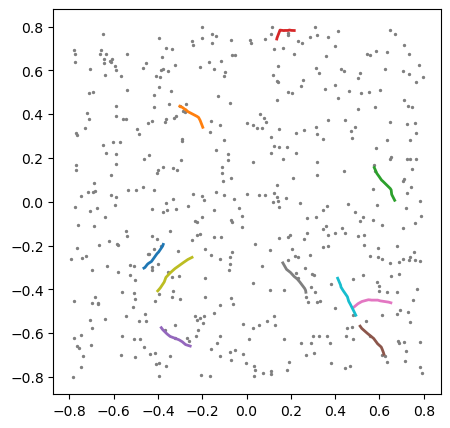

In [96]:
# get a batch of 5 trajectories
inputs, place_outputs, pos = trajectory_generator.get_batch_data()
c0 = place_cells.centers[:, 0].cpu().numpy()
c1 = place_cells.centers[:, 1].cpu().numpy()
pos = pos.cpu().numpy()
# visualize the trajectories
plt.figure(figsize=(5, 5))
plt.scatter(c0, c1, c='gray', s=2)
for i in range(options.batch_size):
    plt.plot(pos[i, :, 0], pos[i, :, 1], lw=2)

First, let's imagine a very long trajectory that almost cover the whole space. For now we ignore the dynamics, so we can achieve this by directly sampling positions at random:

(2000, 2)


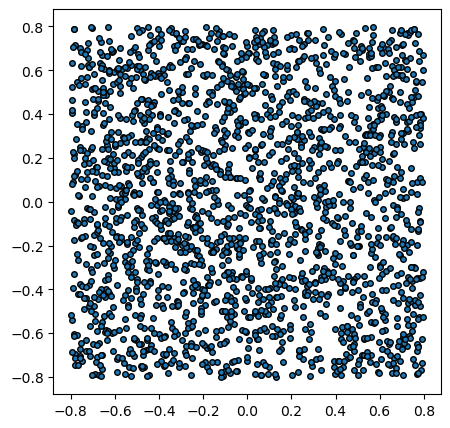

In [65]:
traj_length = 2000
np.random.seed(2)   
usx = np.random.uniform(-options.box_width/2, options.box_width/2, (traj_length,))
usy = np.random.uniform(-options.box_width/2, options.box_width/2, (traj_length,))
pos = np.vstack([usx, usy]).T
print(pos.shape)

# visualize this 500 positions
plt.figure(figsize=(5,5))
plt.scatter(pos[:,0], pos[:,1], edgecolor='k', s=16, c=None)
plt.show()

We now get the place cell representations of these positions on trajectory. Conceptually, to get the classical place fields, we can take the following two steps:

- For each place cell, we get a copy of the above figure
- Then for each figure/place cell, we can color each of the dots according to their distance to the place cell center (`place_cell.us`). The distance is measured by a Gaussian or DoG function.

Therefore, each plot will show **how far each position is to the current place cell's place center**.
Since the positions are dense enough, we get a faithful demonstration of each place cell's place fields. 

In [66]:
pc_outputs = place_cells.get_activation(torch.tensor(pos, dtype=torch.float32, device=device)[None,:,:]).squeeze(0).cpu().numpy()
pc_outputs.shape

(2000, 512)

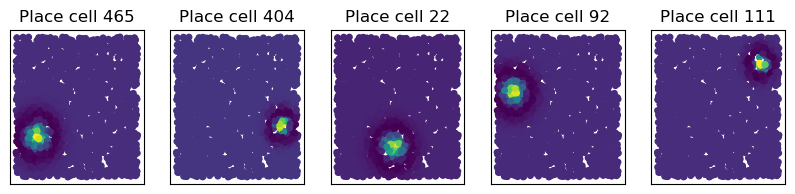

In [67]:
# now we randomly sample 5 place cells and plot their activations mapped onto the positions
n_show = 5
# np.random.seed(0)
select = np.random.choice(np.arange(options.Np), n_show, replace=False)
fig, axes = plt.subplots(1, n_show, figsize=(n_show*2, 2))
for i in range(n_show):
    axes[i].scatter(pos[:,0], pos[:,1], s=16, c=pc_outputs[:,select[i]])
    axes[i].set_title('Place cell {}'.format(select[i]))
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.show()

This provides an intuitive way of understanding the formation of place cells. However, space is continuous, **so we still want to get the 'real' place fields instead of the one represented indirectly by the trajectory, regardless of how long the trajectory is.** To do it, we form a grid up to some resolution level `res` to approximate the full, continuous space. 

torch.Size([50, 50, 2])
torch.Size([50, 50, 512])


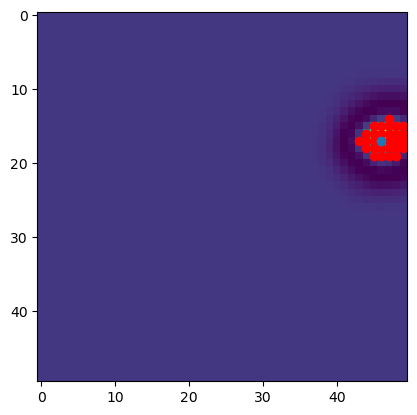

In [68]:
res = 50
grid = np.array(np.meshgrid(np.linspace(-options.box_width/2, options.box_width/2, res),
                         np.linspace(-options.box_height/2, options.box_height/2, res))).T
grid = torch.tensor(grid, device=options.device)

# note that elements of grid are ordered as (y,x) e.g., grid[0,0] is the bottom left corner
# because of meshgrid
print(grid.shape)
grid_pc = place_cells.get_activation(grid)
print(grid_pc.shape)

grid_pc = grid_pc.cpu().numpy().transpose(2,0,1)
sizes = []
for i in range(options.Np):
    peak = find_global_maxima(grid_pc[i])
    area = find_central_field_pixels(grid_pc[i], peak[0], peak[1], size_thresh_scaler=0.2)
    field_size_px, field_size_m = compute_diameter(area, pixel_to_meter=options.box_width/res)
    sizes.append(field_size_m)
plt.imshow(grid_pc[-1])
for a in area:
    plt.scatter(a[1], a[0], c='r')
plt.scatter(peak[1], peak[0])
plt.show()

Text(0.5, 0, 'Place field size (m)')

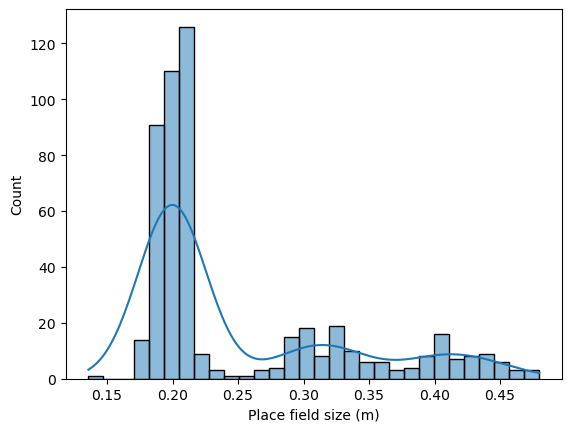

In [69]:
import seaborn as sns
sns.histplot(sizes, bins=30, kde=True)
plt.xlabel('Place field size (m)')

In [70]:
np.mean(sizes), np.std(sizes)

(0.2484350115673834, 0.08075917921520803)

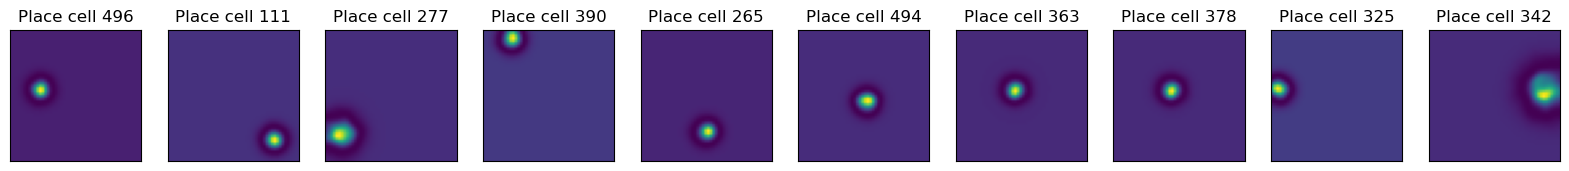

In [71]:
# randomly sample 5 place cells
n_show = 10
# np.random.seed(0)
select = np.random.choice(np.arange(options.Np), n_show, replace=False)
fig, axes = plt.subplots(1, n_show, figsize=(n_show*2, 2))
for i in range(n_show):
    # notice the interpolation arg, which visually makes these 'real' place fields
    axes[i].imshow(grid_pc[select[i]])
    axes[i].set_title('Place cell {}'.format(select[i]))
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.show()

We can think of these as the real place fields, as long as the resolution is large enough. We could then generate the $N_x \times N_x$ spatial covariance matrix, which has a Teoplitz structure:

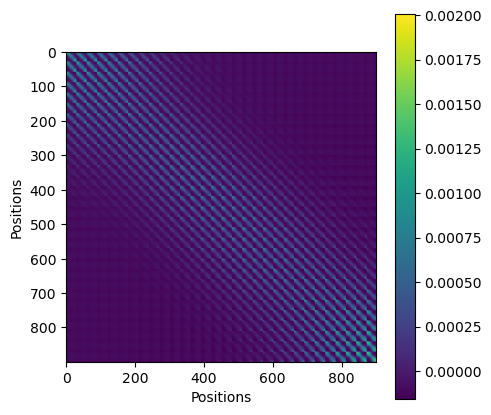

In [9]:
grid_pc = grid_pc.reshape(-1, options.Np)
# spatially center the data
grid_pc = grid_pc - grid_pc.mean(0)
grid_pc_cov = np.cov(grid_pc.cpu().numpy())
plt.figure(figsize=(5,5))
plt.imshow(grid_pc_cov)
plt.xlabel('Positions')
plt.ylabel('Positions')
plt.colorbar()
plt.show()

This matrix measures *'how similar are two positions, meausred as the similarity between their place cell representations or codes?'*

**But why can't a random but dense trajectory give us the Teoplitz structure?**

- The Teoplitz structure comes from the fact that for two positions $p$ and $p'$, we can have some similarity score measured on their place cell codes, $sim(p, p')$. 
- If we move to the same direction by the same amount of step size $\Delta p$, the similarity between $p+\Delta p$ and $p'+\Delta p$ will be the same as the similarity between $p$ and $p'$ i.e., $sim(p, p')=sim(p+\Delta p, p'+\Delta p)$
- This is based on the fact that the positions are equally spaced, to approximate the smooth, continuous 2d environment. In this sense, the $\Sigma_{p, p'}$ and $\Sigma_{p+\Delta p, p'+\Delta p}$ elements of the covariance $\Sigma$ are the same because they exist as points on the grid.
- Now imagine we have $N_x=res\times res$ many positions on a trajectory
- Given any two points $p$ and $p'$ on this trajectory, there is no guarantee that there exist two other points in the trajectory that are exactly $p+\Delta p$ and $p'+\Delta p$.
- In other words, on the covariance matrix of the trajectory, *if we move along the horizontal and vertical coordinates by the same amount, it doesn't mean we have moved by the same spatial amount in the environment! (whereas for the grid data this is the case)*
- This is what Rafal means by 'ordering'.

<img src="images\20240131_114150538_iOS.png" width="500">

Let's now get the eigenvectors of this covariance matrix. Mathematically, say we have the spatial covariance matrix $S_x \in R^{N_x \times N_x}$, its eigendecomposition is:

$$S_x = U\Lambda_x U^T$$

where $U$ is also an $N_x$ by $N_x$ matrix. The columns of $U$ are the eigenvectors of $S_x$: 

In [10]:
# eigendecomposition of covariance matrix
eigvals, eigvecs = np.linalg.eig(grid_pc_cov)
# sort by eigenvalues
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:,idx]
print(eigvecs.shape)

(900, 900)


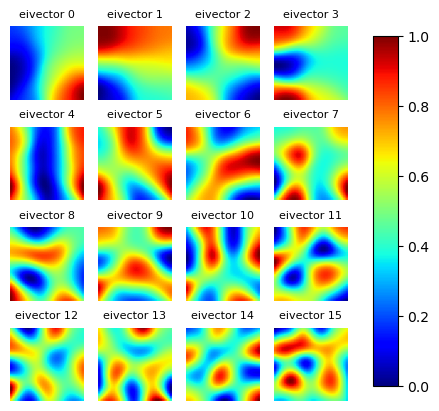

In [11]:
# now select the first 16 eigenvectors and plot them
# visualize eigenvectors
fig, axes = plt.subplots(4, 4, figsize=(5,5))
for i, ax in enumerate(axes.flat):
    gc = eigvecs[:,i].real.reshape((res, res))
    gc = (gc - np.min(gc)) / (np.max(gc) - np.min(gc))
    im = ax.imshow(gc, cmap='jet')
    ax.set_title(f'eivector {i}', fontsize=8)
    ax.axis('off')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

Here, we can already conclude that the grid cells can be regarded as the top-$N_g$ eigenvectors of the spatial covariance matrix $S_x$, which forms a $N_x \times N_g$ matrix i.e., $N_g$ dimensional representation of the original $N_p$ dimensional place cell codes. However, note that the argument of 'grid cells being the principal components of the $N_x \times N_p$ place cell matrix$ still holds. Consider the place cell covariance matrix and its EVD:

$$S_p = V \Lambda_p V^T$$

where $V$ is the $N_p \times N_p$ eigenvectors of $S_p$. The way of getting principal components of $X$ is by extracting the top $N_g$ columns of $V$ and project:

$$X_{principal} = XV_{Ng}$$

However, think of the singular value decomposition of $X$:

$$X = U\Xi V^T \Rightarrow XV=U\Xi$$

We can actually obtain the principal components by scaling each column of $U$ by its corresponding singular value. That is, **the argument that grid cells are eigenvectors (of $S_x$) and principal components (of X) are equally true.**

# Forming trajectories

To begin with, let's first generate a few trajectories and visualize them wrt the place cell centers:

In [7]:
# Training hyperparameters to fully reproduce Sorscher et al. 2023
class Options:
    pass
options = Options()

options.n_steps = 100000      # number of training steps -- this seems to be the epochs in the code
options.batch_size = 200      # number of trajectories per batch
options.sequence_length = 100  # number of steps in trajectory
options.learning_rate = 1e-4  # gradient descent learning rate
options.Np = 512              # number of place cells
options.Ng = 4096             # number of grid cells
options.place_cell_rf = 0.12  # width of place cell center tuning curve (m)
options.surround_scale = 2    # if DoG, ratio of sigma2^2 to sigma1^2
options.RNN_type = 'RNN'      # RNN or LSTM
options.activation = 'relu'   # recurrent nonlinearity
options.weight_decay = 1e-4   # strength of weight decay on recurrent weights
options.DoG = True            # use difference of gaussians tuning curves
options.periodic = False      # trajectories with periodic boundary conditions
options.box_width = 2.2       # width of training environment
options.box_height = 2.2      # height of training environment
options.device = device
options.save_dir = ''
options.run_ID = ''
options.normalize_pc = 'softmax'
options.dt = 0.02

options.decay_step_size = 100
options.decay_rate = 0.9
options.save_dir = 'results'

place_cells = PlaceCells(options)
# model = RNN(options, place_cells).cuda()
trajectory_generator = TrajectoryGenerator(options, place_cells)
# trainer = Trainer(options, model, trajectory_generator)

torch.Size([200, 100, 2])
torch.Size([200, 100, 512])


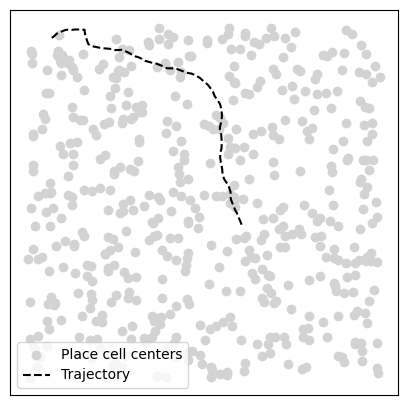

In [11]:
inputs, pc_outputs, pos = trajectory_generator.get_test_batch()
centers = place_cells.centers.cpu()
pos = pos.cpu()

print(pos.shape)
print(pc_outputs.shape)

plt.figure(figsize=(5,5))
plt.scatter(centers[:,0], centers[:,1], c='lightgrey', label='Place cell centers')
for i in range(1):
    plt.plot(pos[i,:,0],pos[i,:,1], label='Trajectory', c='k', ls='--')
    if i==0:
        plt.legend()
plt.xticks([])
plt.yticks([])
plt.show()

The `pc_outputs` are obtained through `place_cells.get_activation` on `pos` within the `trajectory` class. It has shape (20, 200, 512), mearning a batch of 200 trajectory of length 20, represented by 512 place cells. Let's now get the first trajectory in this batch and visualize it with respect to a few place cells:

(1000, 512) (1000, 2)


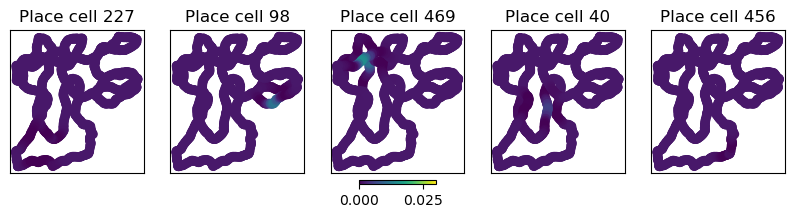

In [16]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

sample_pc = pc_outputs[0].cpu().numpy()
sample_pos = pos[0].cpu().numpy()
print(sample_pc.shape, sample_pos.shape)

# Define colormap and normalization
colormap = plt.cm.viridis  # You can choose any colormap you like
norm = Normalize(vmin=sample_pc.min(), vmax=sample_pc.max())

# plot the first 5 place cells' activation as a function of the trajectory
# add colorbar for all plots
n_show = 5
np.random.seed(5)
select = np.random.choice(np.arange(options.Np), n_show, replace=False)
fig, axes = plt.subplots(1, n_show, figsize=(n_show*2, 2))
for i in range(n_show):
    axes[i].scatter(sample_pos[:,0], sample_pos[:,1], c=sample_pc[:,select[i]], cmap=colormap, norm=norm)
    axes[i].set_title('Place cell {}'.format(select[i]))
    axes[i].set_xticks([])
    axes[i].set_yticks([])
fig.colorbar(ScalarMappable(norm=norm, cmap=colormap), ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.025, pad=0.05)
plt.show()

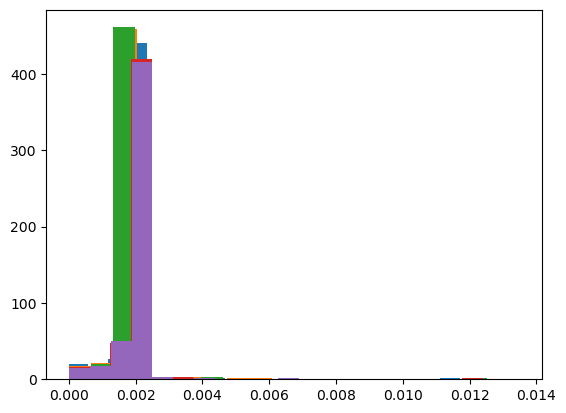

In [17]:
plt.figure()
for i in range(5):
    plt.hist(sample_pc[i], bins=20)
plt.show()

Essentially, each of these subplots shows how a place cell 'sees' the trajectory. For example, place cell 456 will only fire when the agent is at the bottom right corner of the environment on the trajectory. Therefore each column of the pc_output matrix (corresponding to 1 place cell's activity along the trajectory) is sparse.

There is also another way of visualizing the trajectories wrt place cells. Note that now we have:

- $Np \times 2$ center: each of $N_p$ correponding to a center (2d coordinates) of a place cell  
- For each position we visit, we have an 'energy level' vector representing the place cells' joint activities at this position (`pc_outputs[i]`, $N_p$-dim vector)

So for each position on the trajectory, we actually have a function that maps from the place cell centers to how the place cells should respond given the position (Imagine how you color the place cell centers according to their responses to the current position!). We can now represent the trajectory as a sequence of the population of place cells firing:

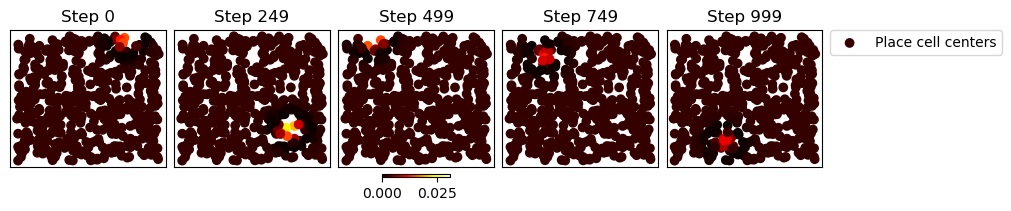

In [12]:
n_show = 5
colormap = plt.cm.hot

# Assuming 'centers' and 'sample_pc' are defined earlier in your code
# centers = ... your centers data
# sample_pc = ... your sample_pc data

inds = np.linspace(0, sample_pc.shape[0]-1, n_show, dtype=int)
fig, axes = plt.subplots(1, n_show, figsize=(n_show*2, 2), constrained_layout=True)

norm = Normalize(vmin=sample_pc.min(), vmax=sample_pc.max())
sm = ScalarMappable(cmap=colormap, norm=norm)

for i in range(n_show):
    sc = axes[i].scatter(centers[:,0], centers[:,1], 
                         c=sample_pc[inds[i]], 
                         label='Place cell centers',
                         cmap=colormap,
                         norm=norm)  # Ensure consistent normalization across subplots
    axes[i].set_title('Step {}'.format(inds[i]))
    axes[i].set_xticks([])
    axes[i].set_yticks([])

# Add colorbar to the right of the subplots
# Adjust the aspect and padding as needed
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.025, pad=0.05)
# cbar.set_label('Colorbar Label')

axes[-1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

plt.show()

Notice that although this visually looks like the place fields of neurons we've seen before, these are not exactly 'place fields'; rather, they are the population firing of place cells, where each dot represents a place cell center, rather than a point on the trajectory.

Alternatively we can make this smoother by interpolating on a grid; this is what Sorscher et al. did in their code. However, as long as $N_p$ is large enough, the above visualization is clear so we don't really need it.

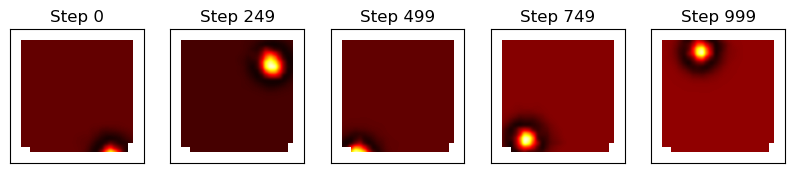

In [109]:
grid_pc = place_cells.grid_pc(sample_pc, res=30)

# visualize 10 steps of trajectory
n_show = 5
inds = np.linspace(0, sample_pc.shape[0]-1, n_show, dtype=int)
fig, axes = plt.subplots(1, n_show, figsize=(n_show*2, 2))
for i in range(n_show):
    axes[i].imshow(grid_pc[inds[i],:,:], interpolation='gaussian', cmap='hot')
    axes[i].set_title('Step {}'.format(inds[i]))
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.show()

# Training an RNN to reproduce Sorscher et al. (2023)

In [2]:
# Training hyperparameters to fully reproduce Sorscher et al. 2023
class Options:
    pass
options = Options()

options.full_size = 100000
options.n_epochs = 100          # number of training epochs
options.n_steps = 1000          # number of batches in one epoch
options.batch_size = 200      # number of trajectories per batch
options.sequence_length = 20  # number of steps in trajectory
options.learning_rate = 1e-4  # gradient descent learning rate
options.Np = 512             # number of place cells
options.Ng = 4096            # number of grid cells
options.place_cell_rf = 0.12  # width of place cell center tuning curve (m)
options.surround_scale = 2    # if DoG, ratio of sigma2^2 to sigma1^2
options.RNN_type = 'RNN'      # RNN or LSTM
options.activation = 'relu'   # recurrent nonlinearity
options.weight_decay = 1e-4   # strength of weight decay on recurrent weights
options.DoG = True            # use difference of gaussians tuning curves
options.periodic = False      # trajectories with periodic boundary conditions
options.box_width = 2.2       # width of training environment
options.box_height = 2.2      # height of training environment
options.device = device
options.save_dir = 'models/'
options.data_source = 'pre'
options.run_ID = generate_run_ID(options)

options.decay_step_size = 5
options.decay_rate = 1

place_cells = PlaceCells(options)
model = RNN(options, place_cells).to(device)
trajectory_generator = TrajectoryGenerator(options, place_cells)
trainer = Trainer(options, model, trajectory_generator)

Restored trained model from models/steps_20_batch_200_RNN_4096_relu_rf_012_DoG_True_periodic_False_lr_00001_weight_decay_00001\most_recent_model.pth


In [4]:
dataset = Trjectory('data/trajectory.npz')
dataloader = torch.utils.data.DataLoader(dataset, batch_size=options.batch_size, shuffle=True)

In [5]:
# get a batch of data
inputs, pc_outputs, pos = next(iter(dataloader))
print(pc_outputs.shape, pos.shape)
torch.nn.functional.one_hot(torch.argmax(pc_outputs, -1),
    num_classes=options.Np
).shape

torch.Size([200, 20, 512]) torch.Size([200, 20, 2])


torch.Size([200, 20, 512])

Epoch: 0/100. Batch 0/250. Loss: 6.238237. Err: 92.78cm
Epoch: 0/100. Batch 1/250. Loss: 6.23818. Err: 95.45cm
Epoch: 0/100. Batch 2/250. Loss: 6.238071. Err: 88.86cm
Epoch: 0/100. Batch 3/250. Loss: 6.238297. Err: 93.12cm
Epoch: 0/100. Batch 4/250. Loss: 6.23816. Err: 91.76cm
Epoch: 0/100. Batch 5/250. Loss: 6.238163. Err: 94.8cm
Epoch: 0/100. Batch 6/250. Loss: 6.238215. Err: 95.38cm
Epoch: 0/100. Batch 7/250. Loss: 6.238171. Err: 95.06cm
Epoch: 0/100. Batch 8/250. Loss: 6.238118. Err: 88.42cm
Epoch: 0/100. Batch 9/250. Loss: 6.238121. Err: 91.43cm
Epoch: 0/100. Batch 10/250. Loss: 6.238215. Err: 95.49cm
Epoch: 0/100. Batch 11/250. Loss: 6.238239. Err: 93.13cm
Epoch: 0/100. Batch 12/250. Loss: 6.238101. Err: 88.52cm
Epoch: 0/100. Batch 13/250. Loss: 6.238245. Err: 90.72cm
Epoch: 0/100. Batch 14/250. Loss: 6.238266. Err: 90.76cm
Epoch: 0/100. Batch 15/250. Loss: 6.238112. Err: 91.23cm
Epoch: 0/100. Batch 16/250. Loss: 6.238217. Err: 92.89cm
Epoch: 0/100. Batch 17/250. Loss: 6.238204. 

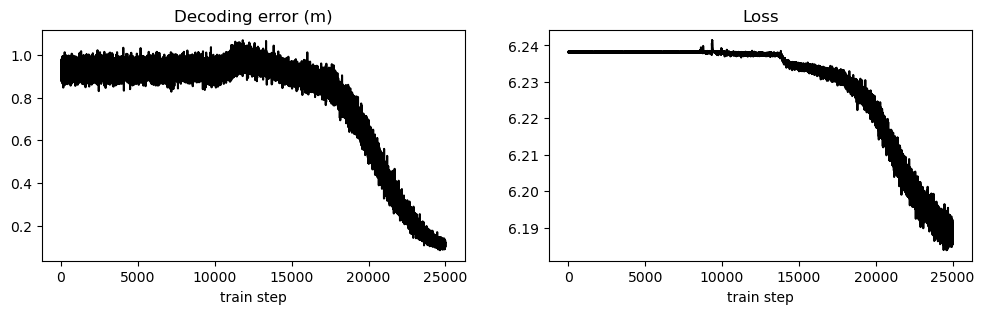

In [6]:
# remember to refresh the model if we want to train a new once!
# otherwise we will continue training the old model
# intial results suggest that the ce loss is 6.24 
# which suggests that the model is randomly guessing which place cell among 512 is active

if options.data_source == 'pre':
    path = f'data/trajectory_{options.full_size}_{options.sequence_length}_{options.Np}.npz'
    # check if the file exists
    if os.path.exists(path):
        print('Loading pre-generated data')
    else:
        print('Generating new data')
        generate_traj_data(options)

    dataloader = get_traj_loader(path, options)
    trainer.train_batch(dataloader, n_epochs=options.n_epochs, save=True)
else:
    trainer.train(n_epochs=options.n_epochs, n_steps=options.n_steps, save=True)

plt.figure(figsize=(12,3))
plt.subplot(121)
plt.plot(trainer.err, c='black')

plt.title('Decoding error (m)'); plt.xlabel('train step')
plt.subplot(122)
plt.plot(trainer.loss, c='black');
plt.title('Loss'); plt.xlabel('train step');

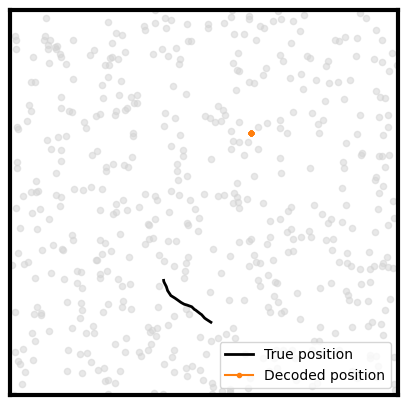

In [10]:
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
pos = pos.cpu()
pred_pos = place_cells.get_nearest_cell_pos(model.predict(inputs)).cpu()
us = place_cells.us.cpu()

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
for i in range(1):
    plt.plot(pos[:,i,0], pos[:,i,1], c='black', label='True position', linewidth=2)
    plt.plot(pred_pos[:,i,0], pred_pos[:,i,1], '.-',
             c='C1', label='Decoded position')
    if i==0:
        plt.legend()
plt.scatter(us[:,0], us[:,1], s=20, alpha=0.5, c='lightgrey')
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3)
plt.xticks([])
plt.yticks([])
plt.xlim([-options.box_width/2,options.box_width/2])
plt.ylim([-options.box_height/2,options.box_height/2]);
# plt.savefig('images/sim_traj_decode.pdf')